In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("sales_data.csv")
display(df)



,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113031,2016-04-12,12,April,2016,41,Adults (35-64),M,United Kingdom,England,Clothing,Vests,"Classic Vest, S",3,24,64,112,72,184
113032,2014-04-02,2,April,2014,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113033,2016-04-02,2,April,2016,18,Youth (<25),M,Australia,Queensland,Clothing,Vests,"Classic Vest, M",22,24,64,655,528,1183
113034,2014-03-04,4,March,2014,37,Adults (35-64),F,France,Seine (Paris),Clothing,Vests,"Classic Vest, L",24,24,64,684,576,1260


In [7]:

df['Date'] = pd.to_datetime(df['Date'])
print(df.isnull().sum())
print("Revenue",df["Revenue"].sum())
print("Total profit",df['Profit'].sum())
print("total Quantity sold",df["Order_Quantity"].sum())


Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64
Revenue 85271008
Total profit 32221100
total Quantity sold 1345316


In [8]:
category_sales = df.groupby('Product_Category')['Revenue'].sum()
print(category_sales)

print("Sales by Sub-category",df.groupby("Sub_Category")["Revenue"].sum())

country_sales = df.groupby('Country')['Revenue'].sum()
print(country_sales)

print("Sales by State",df.groupby("State")["Revenue"].sum())

print("Sales by Age",df.groupby("Customer_Age")["Revenue"].sum())

Product_Category
Accessories    15117992
Bikes          61782134
Clothing        8370882
Name: Revenue, dtype: int64
Sales by Sub-category Sub_Category
Bike Racks             517800
Bike Stands            344075
Bottles and Cages     1409174
Caps                   548777
Cleaners               198821
Fenders               1245733
Gloves                 871419
Helmets               5741081
Hydration Packs        990406
Jerseys               4113742
Mountain Bikes       21123526
Road Bikes           33363061
Shorts                1740710
Socks                  147171
Tires and Tubes       4670902
Touring Bikes         7295547
Vests                  949063
Name: Revenue, dtype: int64
Country
Australia         21302059
Canada             7935738
France             8432872
Germany            8978596
United Kingdom    10646196
United States     27975547
Name: Revenue, dtype: int64
Sales by State State
Alabama                     210
Alberta                   56803
Arizona                    

In [9]:

daily_sales=df.groupby("Date")["Revenue"].sum()
print("Sales daily",daily_sales)

print("Sales monthly",df.groupby("Month")["Revenue"].sum())

Sales daily Date
2011-01-01    12821
2011-01-02    11868
2011-01-03    31175
2011-01-04    18909
2011-01-05     4675
              ...  
2016-07-27    14094
2016-07-28    19102
2016-07-29    19329
2016-07-30    14761
2016-07-31    25570
Name: Revenue, Length: 1884, dtype: int64
Sales monthly Month
April        7602750
August       5711193
December     9086931
February     6834583
January      7005895
July         5721459
June         9043008
March        7347164
May          8836763
November     6244298
October      5995079
September    5841885
Name: Revenue, dtype: int64


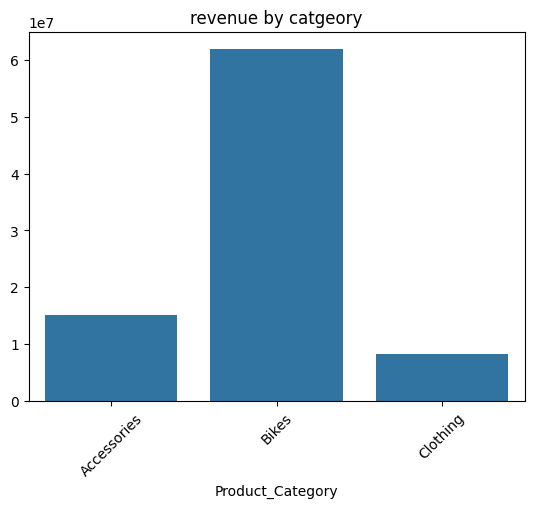

In [ ]:

plt.figure()
sns.barplot(x=category_sales.index,y=category_sales.values)
plt.title("revenue by catgeory")
plt.xticks(rotation=45)
plt.show()

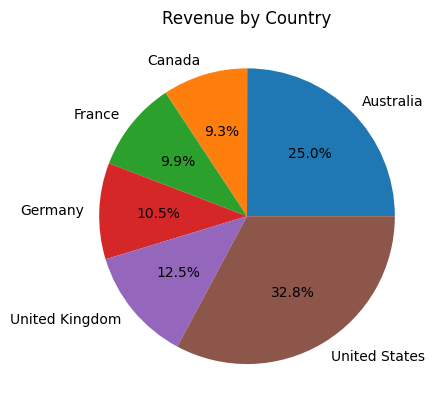

In [11]:
plt.figure()
plt.pie(country_sales.values, labels=country_sales.index, autopct='%1.1f%%')
plt.title("Revenue by Country")
plt.show()

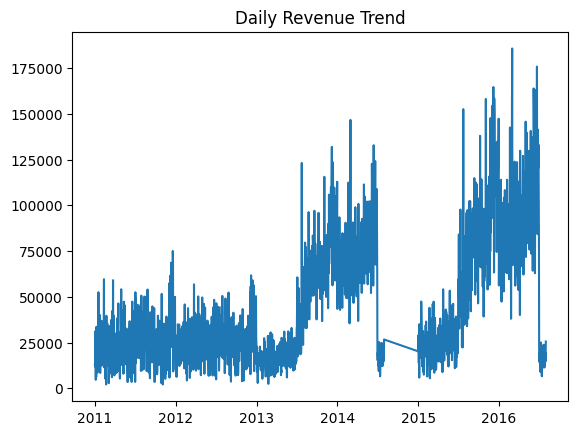

In [12]:
plt.figure()
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Revenue Trend")
plt.show()